In [1]:

from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
from tqdm import tqdm


from refined_progan import Generator, Discriminator
from CityScapes import CityScapesMultiScaleDataset

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
list_to_device = lambda xs,device :[x.to(device) for x in xs]
detach_list = lambda xs: [x.detach() for x in xs]

In [ ]:
z_dim =512
channels = [512,512,256,256,128,128,64]
batch_size =8

In [3]:
dataset = CityScapesMultiScaleDataset()
loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)


Dataset initialized with 19998 samples. Labels enabled: False


In [4]:

gen = Generator(z_dim,channels).to(device)
disc = Discriminator(channels).to(device)

gen_optimizer = Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.999))
disc_optimizer = Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))
noise =  torch.randn(1,z_dim,1,1).to(device)
fake = gen(noise)
disc_fake = disc(fake)

real,_ = next(iter(loader))
real = list_to_device(real,device)
disc_real = disc(real)


/mnt/mydrive/ilias/projects/unsupervised_learning/ECCV/refined_progan/discriminator.py:35: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  batch_statistics =torch.std(x,dim=0).mean().repeat(x.shape[0],1,x.shape[2],x.shape[3])


In [ ]:
epochs =1000

for epoch in range(epochs):
    loop = tqdm(loader)
    loop.set_description("Epoch {}/{}".format(epoch+1,epochs))

    for i, (real,_) in enumerate(loop):
        real = list_to_device(real,device)
        current_batch_size = real[0].shape[0]
        

        disc_optimizer.zero_grad()
        
        noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
        fake = gen(noise)

        disc_fake = disc(detach_list(fake))
        disc_real = disc(real)
        loss_disc =(
        0.5 * (torch.mean(disc_fake) - torch.mean(disc_real))
        + (0.01 * (torch.mean(disc_real ** 2)+torch.mean(disc_fake ** 2)))
        )

        loss_disc.backward()
        disc_optimizer.step()

        gen_optimizer.zero_grad()
        # noise = torch.randn(current_batch_size, z_dim,1,1).to(device)
        # fake = gen(noise)
        disc_fake = disc(fake)
        loss_gen = - torch.mean(disc_fake)

        loss_gen.backward()
        gen_optimizer.step()
        loop.set_postfix(loss_disc=loss_disc.item(),loss_gen=loss_gen.item())





Epoch 1/1000:  28%|██▊       | 698/2500 [00:40<01:44, 17.22it/s, loss_disc=-12.5, loss_gen=25]    

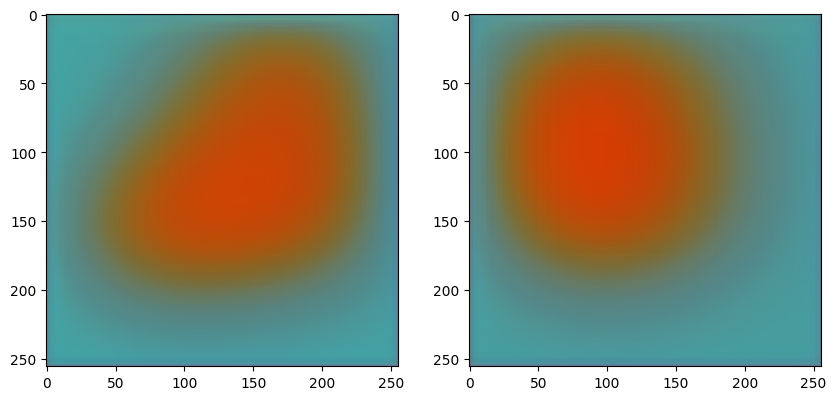

In [8]:
import matplotlib.pyplot as plt
with torch.no_grad():
    noise =torch.randn(8,z_dim,1,1).to(device)
    fake = gen(noise)
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow((fake[-1][0].permute(1,2,0).cpu().numpy()+1)/2)
ax[1].imshow((fake[-1][7].permute(1,2,0).cpu().numpy()+1)/2)


In [ ]:
gen.initial_conv[1].conv.weight.shape

torch.Size([512, 512, 3, 3])

In [ ]:
weight_norm = torch.linalg.vector_norm(gen.initial_conv[1].conv.weight, ord=2, dim=(1, 2, 3), keepdim=True)


In [ ]:
weight_norm.shape

torch.Size([512, 1, 1, 1])

In [ ]:
conv = nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1)
conv.weight.shape
weight_norm = torch.linalg.vector_norm(conv.weight, ord=2, dim=(1, 2, 3), keepdim=True)
scaled_weight = conv.weight / (weight_norm + 1e-8)
scaled_weight

tensor([[[[ 1.0907e-02,  1.2837e-02,  1.3248e-02],
          [-1.7707e-02, -5.6550e-03, -1.6729e-02],
          [ 1.0770e-02, -2.2135e-02, -1.1185e-02]],

         [[ 2.0843e-03, -9.2527e-03, -1.6405e-02],
          [ 1.1864e-02,  2.0992e-02, -7.4373e-03],
          [ 1.1092e-02,  7.2515e-03, -4.4520e-03]],

         [[-1.5053e-04, -2.2960e-02,  1.5740e-02],
          [ 2.1794e-02,  6.3542e-03,  4.1000e-03],
          [-1.7756e-03, -2.2245e-02, -1.1529e-02]],

         ...,

         [[ 8.9752e-03, -2.3906e-02,  1.1532e-02],
          [ 2.2326e-02,  1.6334e-02, -1.0980e-02],
          [-1.4009e-02, -1.7116e-02, -2.0187e-02]],

         [[ 9.6183e-03, -2.3615e-02,  2.3776e-02],
          [ 1.4110e-03, -1.6024e-02, -1.8712e-02],
          [ 2.9001e-04, -9.7027e-03, -2.4132e-02]],

         [[ 8.6386e-03,  1.6754e-02, -7.3961e-03],
          [-1.6869e-02, -1.9692e-02,  2.1958e-02],
          [-1.6268e-02, -2.3664e-02, -8.6141e-03]]],


        [[[-2.2568e-02, -1.6191e-02,  5.9154e-03],
  

In [ ]:
(scaled_weight[2] ** 2).sum() 


tensor(1., grad_fn=<SumBackward0>)